In [1]:
# ============================================================
# EXPERIMENT : ZD_S2_exp03
# STUDY      : S2 — Sampling strategy
# CHANGE     : Full IC (5k+2k bbox+1.5k walls) +
#              slot wall collocation (3k uniform t)
# FIXED      : plain Tanh, w_eik=0.0001, w_ic=10, no causal
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
print('using device:', device)

LAYERS  = 8
NEURONS = 256

class PINN(nn.Module):
    def __init__(self, layers=LAYERS, neurons=NEURONS):
        super().__init__()
        net = [nn.Linear(3, neurons), nn.Tanh()]
        for _ in range(layers - 1):
            net += [nn.Linear(neurons, neurons), nn.Tanh()]
        net += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*net)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

N_f          = 10000
N_i          = 5000
T_final      = 2 * np.pi
adam_epochs  = 20000
lbfgs_epochs = 500

w_pde      = 1.0
w_pde_slot = 5.0
w_ic       = 10.0
w_eik      = 0.0001

XC, YC = 0.5, 0.75
R  = 0.15
W  = R / 6
L  = R
SLOT_YCENTER        = YC - 2 * W
SLOT_YMIN           = SLOT_YCENTER - L
SLOT_YMAX           = SLOT_YCENTER + L
SLOT_Y_LOCAL_CENTER = SLOT_YCENTER - YC
SLOT_Y_LOCAL_MIN    = SLOT_Y_LOCAL_CENTER - L
SLOT_Y_LOCAL_MAX    = SLOT_Y_LOCAL_CENTER + L

print(f'Disc : center=({XC},{YC}), R={R}')
print(f'Slot : X=[{XC-W:.4f},{XC+W:.4f}], Y=[{SLOT_YMIN:.4f},{SLOT_YMAX:.4f}]')

def velocity_field(x, y, t):
    u = -(y - 0.5)
    v =  (x - 0.5)
    return u, v

def initial_condition(x, y):
    phi_circle = torch.sqrt((x - XC)**2 + (y - YC)**2) - R
    slot_x     = torch.abs(x - XC) - W
    slot_y     = torch.abs(y - SLOT_YCENTER) - L
    phi_slot   = torch.maximum(slot_x, slot_y)
    return torch.maximum(phi_circle, -phi_slot)

torch.manual_seed(100)
torch.cuda.manual_seed(100)

# --- Background collocation ---
X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

# --- Background IC ---
x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i_base = torch.cat([x_i, y_i, t_i], dim=1)

# --- Slot bbox IC ---
N_slot = 2000
margin = 0.02
x_slot = (XC - W - margin) + (2*W + 2*margin) * torch.rand(N_slot, 1, device=device)
y_slot = (SLOT_YMIN - margin) + (2*L + 2*margin) * torch.rand(N_slot, 1, device=device)
t_slot = torch.zeros(N_slot, 1, device=device)
X_slot = torch.cat([x_slot, y_slot, t_slot], dim=1)

# --- Slot wall IC ---
N_walls = 500
y_wall  = SLOT_YMIN + 2*L * torch.rand(N_walls, 1, device=device)
x_top   = (XC - W) + 2*W * torch.rand(N_walls, 1, device=device)
y_top   = torch.full((N_walls, 1), SLOT_YMAX, device=device)

X_walls = torch.cat([
    torch.cat([torch.full((N_walls,1), XC-W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([torch.full((N_walls,1), XC+W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([x_top, y_top, torch.zeros(N_walls,1,device=device)], dim=1),
], dim=0)

X_i = torch.cat([X_i_base, X_slot, X_walls], dim=0).detach()

# --- Slot wall collocation — uniform t (NEW in exp03) ---
N_f_slot_walls = 3000
np.random.seed(200)

t_sw    = np.random.rand(N_f_slot_walls)
theta   = 2 * np.pi * t_sw
cos_t   = np.cos(theta);  sin_t = np.sin(theta)
XC_r    = 0.5 + cos_t*(XC-0.5) - sin_t*(YC-0.5)
YC_r    = 0.5 + sin_t*(XC-0.5) + cos_t*(YC-0.5)
side    = np.where(np.random.rand(N_f_slot_walls) > 0.5, -W, W)
yl      = SLOT_Y_LOCAL_MIN + 2*L * np.random.rand(N_f_slot_walls)
xg      = np.clip(XC_r + cos_t*side - sin_t*yl, 0.0, 1.0)
yg      = np.clip(YC_r + sin_t*side + cos_t*yl, 0.0, 1.0)

X_f_slot = torch.tensor(
    np.stack([xg, yg, t_sw], axis=1),
    dtype=torch.float32, device=device
).requires_grad_(True)

print(f'Collocation background   : {X_f.shape[0]}')
print(f'Collocation slot walls   : {X_f_slot.shape[0]}  (uniform t)')
print(f'IC total                 : {X_i.shape[0]}')
print(f'  background             : {N_i}')
print(f'  slot bbox              : {N_slot}')
print(f'  slot walls (t=0)       : {X_walls.shape[0]}')
print(f'T_final                  : {T_final:.4f}')
print(f'Loss weights             : pde={w_pde}, pde_slot={w_pde_slot}, ic={w_ic}, eik={w_eik}')

def pde_residual(Xin):
    phi   = model(Xin)
    grads = torch.autograd.grad(phi, Xin,
                                grad_outputs=torch.ones_like(phi),
                                create_graph=True)[0]
    phi_x = grads[:, 0:1]
    phi_y = grads[:, 1:2]
    phi_t = grads[:, 2:3]
    u, v  = velocity_field(Xin[:,0:1], Xin[:,1:2], Xin[:,2:3])
    res   = phi_t + T_final*(u*phi_x + v*phi_y)
    return res, phi_x, phi_y

def physics_loss(X_f, X_f_slot, X_i):
    res_f, phi_x_f, phi_y_f = pde_residual(X_f)
    loss_pde = torch.mean(res_f**2)

    res_s, _, _ = pde_residual(X_f_slot)
    loss_pde_slot = torch.mean(res_s**2)

    phi_pred = model(X_i)
    phi_true = initial_condition(X_i[:,0:1], X_i[:,1:2])
    loss_ic  = torch.mean((phi_pred - phi_true)**2)

    norm_grad = torch.sqrt(phi_x_f**2 + phi_y_f**2 + 1e-8)
    loss_eik  = torch.mean((norm_grad - 1.0)**2)

    total = (w_pde      * loss_pde
           + w_pde_slot * loss_pde_slot
           + w_ic       * loss_ic
           + w_eik      * loss_eik)
    return loss_pde, loss_pde_slot, loss_ic, loss_eik, total

Mounted at /content/drive
Tesla T4
using device: cuda
Disc : center=(0.5,0.75), R=0.15
Slot : X=[0.4750,0.5250], Y=[0.5500,0.8500]
Collocation background   : 10000
Collocation slot walls   : 3000  (uniform t)
IC total                 : 8500
  background             : 5000
  slot bbox              : 2000
  slot walls (t=0)       : 1500
T_final                  : 6.2832
Loss weights             : pde=1.0, pde_slot=5.0, ic=10.0, eik=0.0001


In [ ]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'pde_slot': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_pde_slot, loss_ic, loss_eik, loss = physics_loss(X_f, X_f_slot, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['pde_slot'].append(loss_pde_slot.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam {epoch} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | pde slot {loss_pde_slot.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam {adam_epochs} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | pde slot {loss_pde_slot.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_pde_slot, loss_ic, loss_eik, loss = physics_loss(X_f, X_f_slot, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['pde_slot'] = loss_pde_slot.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['pde_slot'].append(loss_store['pde_slot'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS {epoch} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | pde slot {loss_store['pde_slot']} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS {lbfgs_epochs} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | pde slot {loss_store['pde_slot']} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/ZD_S2_exp03.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam 0 | total 3.060e+00 | pde 4.016e-01 | pde slot 1.155e-01 | ic 2.081e-01 | eik 4.251e-01 | LR 1.000e-03
Adam 2000 | total 1.301e-02 | pde 5.573e-03 | pde slot 4.021e-04 | ic 5.414e-04 | eik 1.025e-01 | LR 8.100e-04
Adam 4000 | total 1.055e-02 | pde 4.298e-03 | pde slot 6.701e-04 | ic 2.890e-04 | eik 9.571e-02 | LR 6.561e-04
Adam 6000 | total 2.447e-03 | pde 5.805e-04 | pde slot 3.631e-05 | ic 1.677e-04 | eik 8.433e-02 | LR 5.314e-04
Adam 8000 | total 1.832e-03 | pde 3.712e-04 | pde slot 2.248e-05 | ic 1.341e-04 | eik 7.912e-02 | LR 4.305e-04
Adam 10000 | total 1.585e-03 | pde 2.406e-04 | pde slot 2.083e-05 | ic 1.232e-04 | eik 7.671e-02 | LR 3.487e-04
Adam 12000 | total 1.876e-03 | pde 6.087e-04 | pde slot 3.490e-05 | ic 1.086e-04 | eik 7.257e-02 | LR 2.824e-04
Adam 14000 | total 1.166e-03 | pde 1.702e-04 | pde slot 1.690e-05 | ic 9.040e-05 | eik 7.003e-02 | LR 2.288e-04
Adam 16000 | total 1.115e-03 | pde 3.317e-04 | pde slot 1.527e-05 | ic 7.002e-05 | eik 6.919e-02 | LR 1.853e-04


In [2]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/ZD_S2_exp03.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


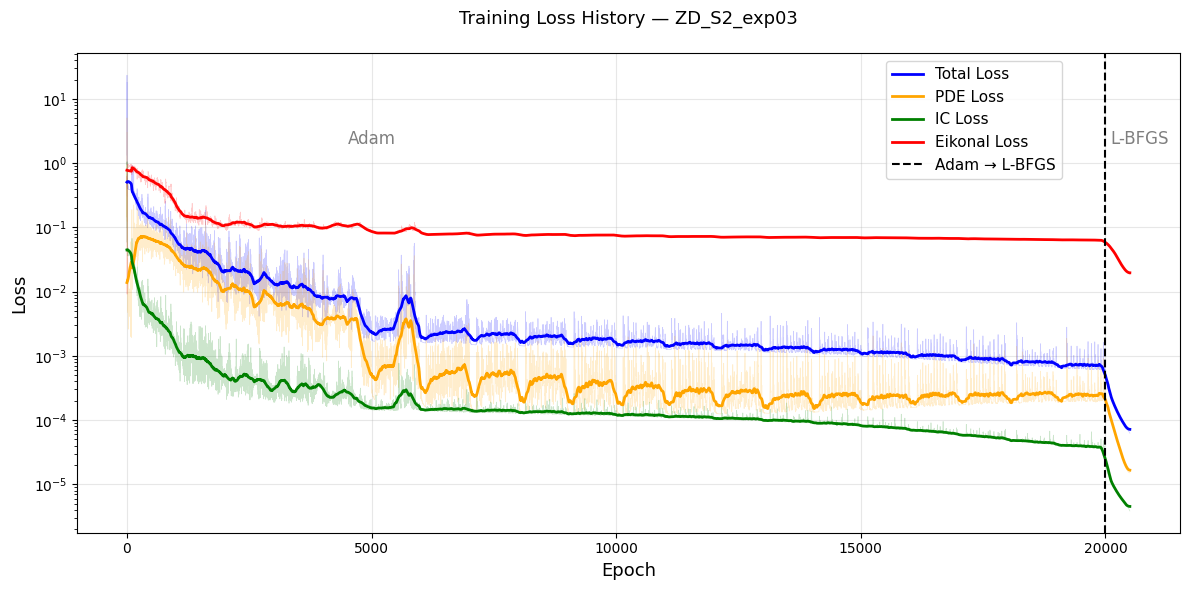

Saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

history = checkpoint['history']
epochs = np.array(history['epoch'])
total  = np.array(history['total'])
pde    = np.array(history['pde'])
ic     = np.array(history['ic'])
eik    = np.array(history['eik'])

fig, ax = plt.subplots(figsize=(12, 6))

# Raw losses
colors = {'total': 'blue', 'pde': 'orange', 'ic': 'green', 'eik': 'red'}
ax.semilogy(epochs, total, color=colors['total'], alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, pde,   color=colors['pde'],   alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, ic,    color=colors['ic'],    alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, eik,   color=colors['eik'],   alpha=0.2, linewidth=0.5)

# Smoothed trend lines
window = 200
for data, color, label in [
    (total, colors['total'], 'Total Loss'),
    (pde,   colors['pde'],   'PDE Loss'),
    (ic,    colors['ic'],    'IC Loss'),
    (eik,   colors['eik'],   'Eikonal Loss'),
]:
    log_smoothed = uniform_filter1d(
        np.log10(np.clip(data, 1e-12, None)), size=window
    )
    ax.semilogy(epochs, 10**log_smoothed, color=color, linewidth=2, label=label)

# Adam / LBFGS separator
ax.axvline(x=adam_epochs, color='black', linestyle='--',
           linewidth=1.5, label='Adam → L-BFGS')
ax.text(5000, 2.0,  'Adam',   fontsize=12, ha='center', color='black', alpha=0.5)
ax.text(20100, 2.0,  'L-BFGS', fontsize=12, ha='left',   color='black', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss',  fontsize=13)
ax.set_title(
    'Training Loss History — ZD_S2_exp03\n',
    fontsize=13
)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(0.90, 1.00))
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_training_loss_ZD_S2_exp03.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

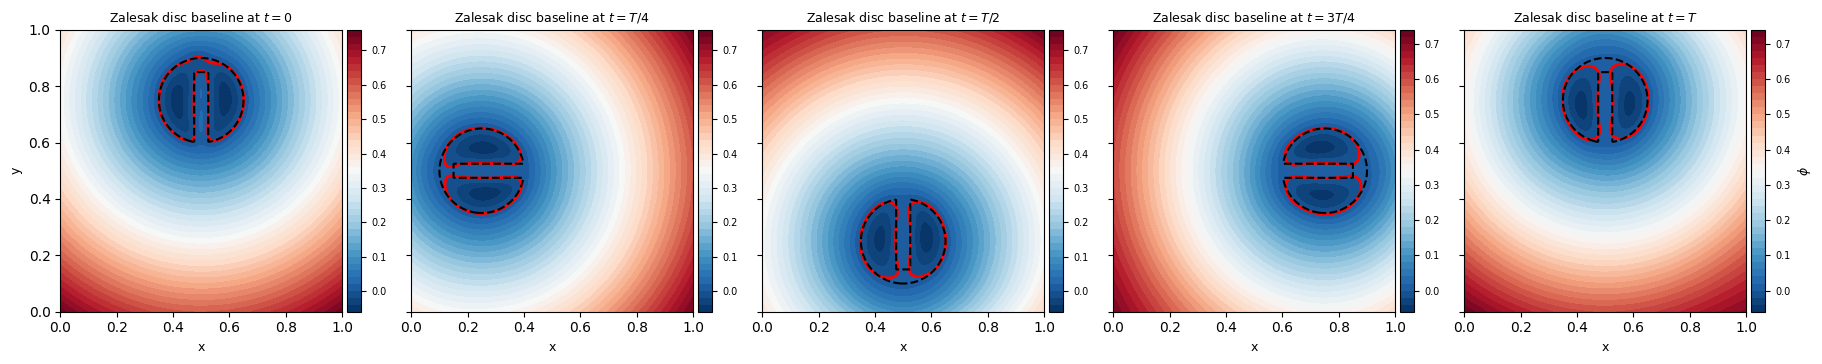

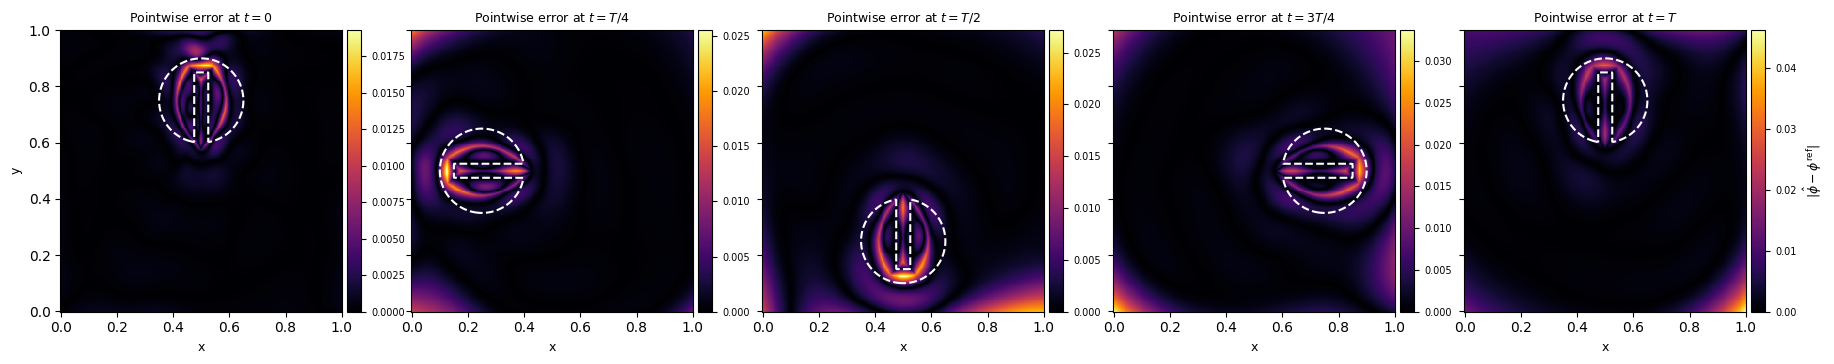


Snapshot           abs L2   rel L2 (%)     Mass err
--------------------------------------------------
t=0.00          1.32e-03        0.38%      5.03e-04
t=1.57          2.49e-03        0.71%      2.73e-03
t=3.14          3.55e-03        1.02%      3.22e-03
t=4.71          3.73e-03        1.07%      3.05e-03
t=6.28          4.32e-03        1.24%      3.13e-03
--------------------------------------------------
avg              3.08e-03        0.89%      2.53e-03


In [3]:
# ==============================================================
# CELL 4: VISUALIZATION
# Figure 1: phi field (1 row x 5 cols, per-snapshot colorbar)
# Figure 2: error field (1 row x 5 cols, per-snapshot colorbar)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx = 300

x_1d = np.linspace(0, 1, nx)
y_1d = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x_1d, y_1d)
dx = dy = x_1d[1] - x_1d[0]

def exact_phi_rotated(X, Y, t):
    theta = 2 * np.pi * t / T_final
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x0, y0 = 0.5, 0.5
    dx_c = XC - x0;  dy_c = YC - y0
    XC_t = x0 + cos_t*dx_c - sin_t*dy_c
    YC_t = y0 + sin_t*dx_c + cos_t*dy_c
    dX = X - XC_t;  dY = Y - YC_t
    X_loc =  cos_t*dX + sin_t*dY
    Y_loc = -sin_t*dX + cos_t*dY
    phi_circle = np.sqrt(dX**2 + dY**2) - R
    slot_x = np.abs(X_loc) - W
    slot_y = np.abs(Y_loc - (SLOT_YCENTER - YC)) - L
    phi_slot = np.maximum(slot_x, slot_y)
    return np.maximum(phi_circle, -phi_slot)

# Collect data
phi_preds, phi_refs = [], []
l2_abs_list, l2_rel_list, mass_abs_list = [], [], []

for t_val in times:
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device)
    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, nx)
    phi_ref = exact_phi_rotated(X, Y, t_val)
    phi_preds.append(phi_pred)
    phi_refs.append(phi_ref)

    l2_abs = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    l2_rel = np.sqrt(np.sum((phi_pred - phi_ref)**2)) / np.sqrt(np.sum(phi_ref**2)) * 100
    mass_pred = np.sum(phi_pred < 0) * dx * dy
    mass_ref  = np.sum(phi_ref  < 0) * dx * dy
    mass_abs  = abs(mass_pred - mass_ref)

    l2_abs_list.append(l2_abs)
    l2_rel_list.append(l2_rel)
    mass_abs_list.append(mass_abs)

errors = [np.abs(phi_preds[i] - phi_refs[i]) for i in range(5)]
tlabels = ['t=0', 't=T/4', 't=T/2', 't=3T/4', 't=T']

from mpl_toolkits.axes_grid1 import ImageGrid

# ══════════════════════════════════════════════════════
# Figure 1: Predicted φ field
# ══════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 5))
grid1 = ImageGrid(fig1, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid1):
    im = ax.contourf(X, Y, phi_preds[i], levels=50, cmap='RdBu_r')
    ax.contour(X, Y, phi_preds[i], levels=[0], colors='red',   linewidths=2)
    ax.contour(X, Y, phi_refs[i],  levels=[0], colors='black', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Zalesak disc baseline at ${tlabels[i]}$', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid1.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$\phi$', fontsize=9)   # ← only on last
#plt.savefig('/content/drive/MyDrive/fig_ZD_S2_exp03_phi.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ══════════════════════════════════════════════════════
# Figure 2: Pointwise error
# ══════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 5))
grid2 = ImageGrid(fig2, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid2):
    im = ax.pcolormesh(X, Y, errors[i], cmap='inferno',
                       vmin=0, vmax=errors[i].max(), shading='auto')
    ax.contour(X, Y, phi_refs[i], levels=[0], colors='white', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Pointwise error at ${tlabels[i]}$', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid2.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$|\hat{\phi}-\phi^{\rm ref}|$', fontsize=9)  # ← only on last
#plt.savefig('/content/drive/MyDrive/fig_ZD_S2_exp03_errors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Summary
print(f"\n{'Snapshot':<12} {'abs L2':>12} {'rel L2 (%)':>12} {'Mass err':>12}")
print('-' * 50)
for t_val, l2a, l2r, me in zip(times, l2_abs_list, l2_rel_list, mass_abs_list):
    print(f't={t_val:<8.2f}  {l2a:>12.2e}  {l2r:>10.2f}%  {me:>12.2e}')
print('-' * 50)
print(f"{'avg':<12} {np.mean(l2_abs_list):>12.2e}  "
      f"{np.mean(l2_rel_list):>10.2f}%  {np.mean(mass_abs_list):>12.2e}")

In [4]:
import csv
import numpy as np

# CONFIG
EXP_ID           = 'ZD_S2_exp03'
BENCHMARK        = 'ZD'
SAMPLING         = 'IC_8.5k_uniform5k_bbox2k_walls1.5k_colloc_13k_uniform10k_slotwalls3k'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/ZD_S2_sampling_study.csv'

row = {
    'exp_id':            EXP_ID,
    'benchmark':         BENCHMARK,
    'N_f':               N_f,
    'N_i':               N_i,
    'layers':            LAYERS,
    'neurons':           NEURONS,
    'w_pde':             w_pde,
    'w_ic':              w_ic,
    'w_eik':             w_eik,
    'adam_epochs':       adam_epochs,
    'lbfgs_epochs':      lbfgs_epochs,
    'scheduler':         SCHEDULER,
    'scheduler_params':  SCHEDULER_PARAMS,
    'sampling':          SAMPLING,
    't_normalized':      T_NORMALIZED,
    # abs L2 per snapshot
    'L2abs_t0':          f'{l2_abs_list[0]:.2e}',
    'L2abs_tT4':         f'{l2_abs_list[1]:.2e}',
    'L2abs_tT2':         f'{l2_abs_list[2]:.2e}',
    'L2abs_t3T4':        f'{l2_abs_list[3]:.2e}',
    'L2abs_tT':          f'{l2_abs_list[4]:.2e}',
    'avg_L2abs':         f'{np.mean(l2_abs_list):.2e}',
    # rel L2 (%) per snapshot
    'L2rel(%)_t0':       f'{l2_rel_list[0]:.2f}%',
    'L2rel(%)_tT4':      f'{l2_rel_list[1]:.2f}%',
    'L2rel(%)_tT2':      f'{l2_rel_list[2]:.2f}%',
    'L2rel(%)_t3T4':     f'{l2_rel_list[3]:.2f}%',
    'L2rel(%)_tT':       f'{l2_rel_list[4]:.2f}%',
    'avg_L2rel(%)':      f'{np.mean(l2_rel_list):.2f}%',
    # mass error per snapshot
    'mass_t0':           f'{mass_abs_list[0]:.2e}',
    'mass_tT4':          f'{mass_abs_list[1]:.2e}',
    'mass_tT2':          f'{mass_abs_list[2]:.2e}',
    'mass_t3T4':         f'{mass_abs_list[3]:.2e}',
    'mass_tT':           f'{mass_abs_list[4]:.2e}',
    'avg_mass':          f'{np.mean(mass_abs_list):.2e}',
    'training_time':     checkpoint['training_time'],
}

write_header = False
try:
    with open(CSV_PATH, 'r') as f:
        write_header = (f.read(1) == '')
except FileNotFoundError:
    write_header = True

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/ZD_S2_sampling_study.csv
